In [ ]:
# Core imports for data handling, plotting, and numerical work
import pandas as pd
import plotly.graph_objects as go
import numpy as np

# Load Pareto frontier CSV for the decision-making GA
# NOTE: update path as per local relative path
df = pd.read_csv("SNN_GA/results/snn_ga_decision_making/frontier_full_recomputed.csv")

# Extract normalised objective values from CSV
# pre_norm  : normalised RMSE for pre-stimulus bias (Y_I)
# sep_norm  : normalised RMSE for decision separation (Y_II)
# psd_norm  : normalised RMSE for PSD peak
RMSE1_n = df["pre_norm"].values
RMSE2_n = df["sep_norm"].values
PSD_RMSE_n = df["psd_norm"].values

# Composite L2 (if not already in CSV)
if "composite" in df.columns:
    RMSE_overall = df["composite"].values
else:
    RMSE_overall = np.sqrt(RMSE1_n**2 + RMSE2_n**2 + PSD_RMSE_n**2)

# Optional: include params in hover text if CSV contains them
if {"ge", "gi", "sparsity", "thalamic_ex", "thalamic_in"}.issubset(df.columns):
    hover_text = [
        f"ge={row.ge:.4f}, gi={row.gi:.4f}, sparsity={row.sparsity:.3f}, th_ex={row.thalamic_ex:.3f}, th_in={row.thalamic_in:.3f}"
        for _, row in df.iterrows()
    ]
else:
    hover_text = [""] * len(df)

# 3D Pareto frontier plot in objective space
fig = go.Figure(data=[go.Scatter3d(
    x=RMSE1_n,          # Normalised Y_I RMSE
    y=RMSE2_n,          # Normalised Y_II RMSE
    z=PSD_RMSE_n,       # Normalised frequency RMSE
    mode='markers',
    marker=dict(
        size=5,
        color=RMSE_overall, # colour by composite RMSE
        colorscale='Viridis',
        colorbar=dict(
            title="Normalised Overall RMSE",
            len=0.5,        # reduce length
            thickness=20
        ),
        opacity=0.9
    ),
    text=hover_text,
    hovertemplate=
        "RMSE1_n: %{x:.3f}<br>" +
        "RMSE2_n: %{y:.3f}<br>" +
        "PSD_RMSE_n: %{z:.3f}<br>" +
        "Lowest overall RMSE of %{marker.color:.3f}<br>" +
        "%{text}<extra></extra>"
)])
# Axis labels and layout
fig.update_layout(
    scene=dict(
        xaxis=dict(
            title=dict(
                text="<br><br><br>Normalised Y<sub>I</sub> RMSE",
                font=dict(size=22)
            ),
            tickfont=dict(size=14)
        ),
        yaxis=dict(
            title=dict(
                text="<br><br><br>Normalised Y<sub>II</sub> RMSE",
                font=dict(size=22)
            ),
            tickfont=dict(size=14)
        ),
        zaxis=dict(
            title=dict(
                text="<br><br><br>Normalised Frequency RMSE",
                font=dict(size=22)
            ),
            tickfont=dict(size=14)
        ),
    ),
    width=1000,
    height=900
)
# Colourbar styling
fig.data[0].marker.colorbar.tickfont = dict(size=20)
fig.data[0].marker.colorbar.title.font = dict(size=24)
fig.data[0].marker.colorbar.title.side = "right"

fig.show()


In [ ]:
# Path to NPZ file containing best-run raw data (four-case structure, trial outputs, etc.)
# NOTE: update path as per local relative path
npz_path_of_run = "SNN_GA/results/snn_ga_decision_making/raw_data_best.npz"

In [ ]:
def pick_best_trial_for_case(trials, winner="E1", lambda_bias=2.0):
    """
    Select the 'best' trial for a given case based on:
      - low pre-stimulus bias between E1 and E2
      - high separation in the decision window for the chosen winner (E1 or E2)

    trials      : list of trial dicts with spikeCountE1/E2 and time
    winner      : "E1" or "E2" — which pool should dominate in decision window
    lambda_bias : weight penalising pre-stimulus bias
    """
    dt_sec = 1e-3
    NE1, NE2 = 200, 200

    best_score = -np.inf
    best_trial = None

    for out in trials:
        time = out["time"]
        sE1 = out["spikeCountE1"]
        sE2 = out["spikeCountE2"]

        # Pre-stimulus window: 0–500 ms
        mask_pre = (time >= 0) & (time < 500)
        T_pre = np.sum(mask_pre) * dt_sec
        rE1_pre = np.sum(sE1[mask_pre]) / (NE1 * T_pre)
        rE2_pre = np.sum(sE2[mask_pre]) / (NE2 * T_pre)
        pre_bias = abs(rE1_pre - rE2_pre)

        # Decision window: 500–1500 ms
        mask_mid = (time >= 500) & (time < 1500)
        T_mid = np.sum(mask_mid) * dt_sec
        rE1_mid = np.sum(sE1[mask_mid]) / (NE1 * T_mid)
        rE2_mid = np.sum(sE2[mask_mid]) / (NE2 * T_mid)
        # Separation in favour of the chosen winner
        if winner == "E1":
            sep = rE1_mid - rE2_mid
        else:
            sep = rE2_mid - rE1_mid
        # Score: large separation, small pre-bias
        score = sep - lambda_bias * pre_bias

        if score > best_score:
            best_score = score
            best_trial = out

    return best_trial

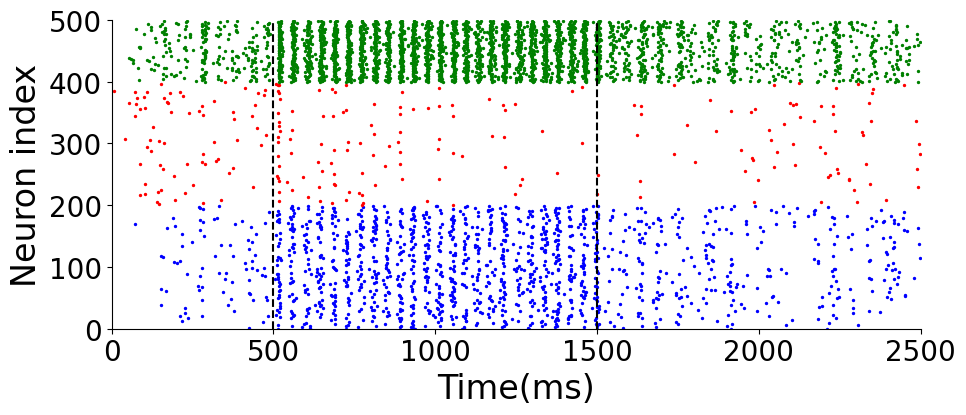

In [ ]:
# Raster plot for the GA-selected best trial in case 1
import matplotlib.pyplot as plt
# Load NPZ containing four-case structure
# NOTE: update path as per local relative path (kept consistent with npz_path_of_run)
data = np.load(npz_path_of_run, allow_pickle=True)
four_case = data["four_case"].item()

# Recompute the GA-selected best trial for case 1 (E1 winner)

best_trial = pick_best_trial_for_case(
    four_case["case1"]["trials"],
    winner="E1"
)

out = best_trial

time = out["time"]
R1 = out["spikeRasterE1"]   # raster for E1 population
R2 = out["spikeRasterE2"]   # raster for E2 population
RI = out["spikeRasterI"]    # raster for inhibitory population

fig, ax = plt.subplots(figsize=(10, 4.5))
# Plot E1 spikes (rows 0–199)
rows, cols = np.where(R1)
ax.scatter(time[cols], rows, s=2, color="blue")
# Plot E2 spikes (rows 200–399)
rows, cols = np.where(R2)
ax.scatter(time[cols], rows + 200, s=2, color="red")
# Plot inhibitory spikes (rows 400–499)
rows, cols = np.where(RI)
ax.scatter(time[cols], rows + 400, s=2, color="green")
# Stimulus onset/offset markers
ax.axvline(500, linestyle="--", color="k")
ax.axvline(1500, linestyle="--", color="k")

ax.set_xlim(0, 2500)
ax.set_ylim(0, 500)
ax.set_ylabel("Neuron index", fontsize=24)
ax.set_xlabel("Time(ms)", fontsize=24)
ax.tick_params(axis="y", labelsize=20)
ax.tick_params(axis="x", labelsize=20)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
# Optionally auto-save figure:
# fig.savefig("panelA_raster_nsga3.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# Load saved trial outputs for PSD epoch analysis
# NOTE: update path as per local relative path
data = np.load("SNN_GA/results/snn_ga_decision_making/raw_data_best.npz", allow_pickle=True)
trial_outputs = data["trial_outputs"]

dt = 1.0 # ms per step
dt_sec = dt / 1000.0

In [ ]:
# Epoch boundaries in ms (and corresponding indices)
idx0 = int(0 / dt)
idx1 = int(500 / dt)
idx2 = int(1500 / dt)
idx3 = int(2500 / dt)

def compute_psd(seg):
    """
    Compute PSD of a segment of I_sum using rFFT and Hanning window.
    Returns:
        faxis : frequency axis (Hz)
        Sxx   : PSD values
    """
    seg = seg - np.mean(seg)
    N = len(seg)
    if N <= 1:
        return None, None
    window = np.hanning(N)
    Xw = seg * window
    xf = np.fft.rfft(Xw)
    Sxx = np.real((2 * dt_sec**2 / (N * dt_sec)) * (xf * np.conj(xf)))
    faxis = np.fft.rfftfreq(N, d=dt_sec)
    return faxis, Sxx

psd_I_list = [] # PSDs for epoch I (0–500 ms)
psd_II_list = []   # PSDs for epoch II (500–1500 ms)
psd_III_list = []  # PSDs for epoch III (1500–2500 ms)

for out in trial_outputs:
    I = out["I_sum"]

    f1, S1 = compute_psd(I[idx0:idx1])
    f2, S2 = compute_psd(I[idx1:idx2])
    f3, S3 = compute_psd(I[idx2:idx3])

    psd_I_list.append(S1)
    psd_II_list.append(S2)
    psd_III_list.append(S3)


In [ ]:
# Convert PSD lists to mean PSDs across trials for each epoch
psd_I_mean = np.mean(np.stack(psd_I_list), axis=0)
psd_II_mean = np.mean(np.stack(psd_II_list), axis=0)
psd_III_mean = np.mean(np.stack(psd_III_list), axis=0)

In [ ]:
# Bundle PSD data with labels and y-limits for insets
psd_data = [
    ("I", f1, psd_I_mean, 250),
    ("II", f2, psd_II_mean, 950),
    ("III", f3, psd_III_mean, 250),
]

In [ ]:
# Global plotting style for PSD insets (and later for rates)
plt.rcParams.update({
        "font.size": 16,
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 16,
        "figure.titlesize": 22,
        "axes.spines.top": False,
        "axes.spines.right": False,
    })

In [ ]:
# Now build the firing-rate panel with PSD insets (Panel B)
import numpy as np
import matplotlib.pyplot as plt

# NOTE: update path as per local relative path
npz_path = "SNN_GA/results/snn_ga_decision_making/raw_data_best.npz"
data = np.load(npz_path, allow_pickle=True)
four_case = data["four_case"].item()

# Combine all trials from both decision cases
trials = four_case["case1"]["trials"] + four_case["case2"]["trials"]
print("Total trials:", len(trials))

Total trials: 30


In [ ]:
# Population sizes and smoothing kernel for firing rates
NE1, NE2, NI = 200, 200, 100
smooth = np.ones(50) / 50  # 50-bin moving average
dt_sec = 1e-3

In [ ]:
def compute_smoothed_rates(trial):
    time = trial["time"]
    sE1 = trial["spikeCountE1"]
    sE2 = trial["spikeCountE2"]
    sI  = trial["spikeCountI"]
    # Convolve spike counts and convert to Hz
    rE1 = np.convolve(sE1, smooth, mode="same") * (1000 / NE1)
    rE2 = np.convolve(sE2, smooth, mode="same") * (1000 / NE2)
    rI  = np.convolve(sI,  smooth, mode="same") * (1000 / NI)

    return time, rE1, rE2, rI

In [ ]:
def classify_trial(trial):
    """
    Classify a trial as 'E1' or 'E2' winner based on mean firing
    in the decision window (500–1500 ms).
    """
    time = trial["time"]
    sE1 = trial["spikeCountE1"]
    sE2 = trial["spikeCountE2"]

    mask = (time >= 500) & (time <= 1500)
    T = np.sum(mask) * dt_sec

    mE1 = np.sum(sE1[mask]) / (NE1 * T)
    mE2 = np.sum(sE2[mask]) / (NE2 * T)

    return "E1" if mE1 > mE2 else "E2"


In [ ]:
# Split trials into E1-win and E2-win groups
E1win_rates = []
E2win_rates = []

for tr in trials:
    """
    Average E1 and E2 firing-rate traces across a group of trials.
    group: list of (rE1, rE2) tuples.
    """
    label = classify_trial(tr)
    _, rE1, rE2, _ = compute_smoothed_rates(tr)

    if label == "E1":
        E1win_rates.append((rE1, rE2))
    else:
        E2win_rates.append((rE1, rE2))

print("E1-win trials:", len(E1win_rates))
print("E2-win trials:", len(E2win_rates))


E1-win trials: 16
E2-win trials: 14


In [22]:
def avg_group(group):
    rE1_list = [g[0] for g in group]
    rE2_list = [g[1] for g in group]
    return np.mean(rE1_list, axis=0), np.mean(rE2_list, axis=0)

E1win_E1, E1win_E2 = avg_group(E1win_rates)
E2win_E1, E2win_E2 = avg_group(E2win_rates)

time = trials[0]["time"]


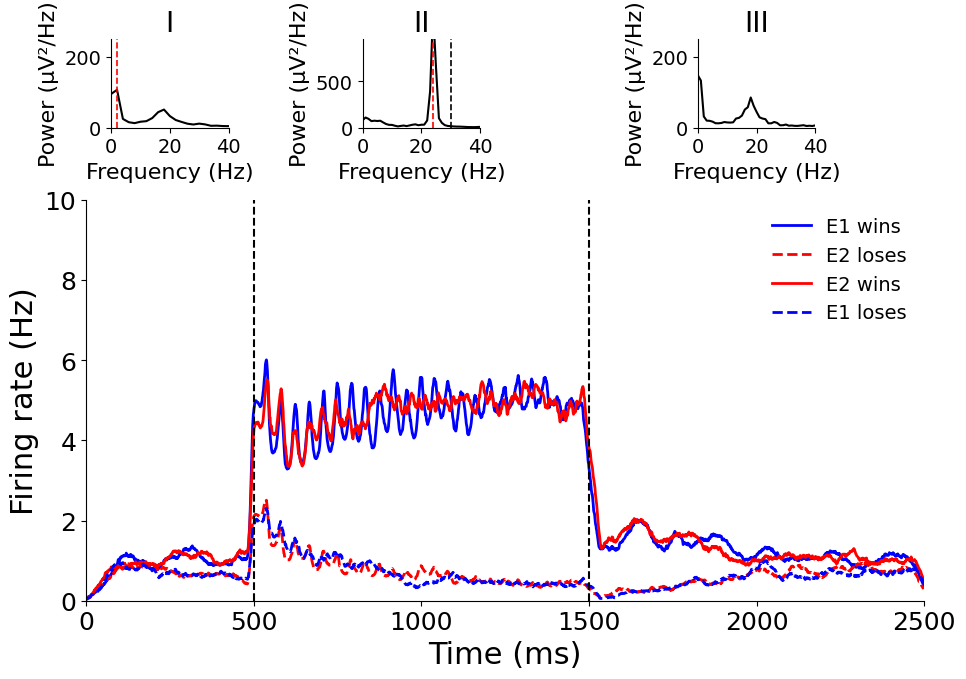

In [ ]:
# Plot averaged firing rates for E1-win and E2-win groups + PSD insets
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 14,
    "figure.titlesize": 22,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, ax = plt.subplots(figsize=(10, 8.0))

# E1-win group: E1 solid, E2 dashed
ax.plot(time, E1win_E1, color="blue",  linestyle="-",  linewidth=2, label="E1 wins")
ax.plot(time, E1win_E2, color="red", linestyle="--", linewidth=2, label="E2 loses")

# E2-win group: E2 solid, E1 dashed
ax.plot(time, E2win_E2, color="red", linestyle="-",  linewidth=2, label="E2 wins")
ax.plot(time, E2win_E1, color="blue",  linestyle="--", linewidth=2, label="E1 loses")

# Decision epoch boundaries
ax.axvline(500, linestyle="--", color="k")
ax.axvline(1500, linestyle="--", color="k")
# ax.axhline(7, color="gray", linestyle="--", linewidth=1)
# ax.axhline(1, color="gray", linestyle="--", linewidth=1)

ax.set_ylim(0, 10)
ax.set_xlim(0, 2500)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Firing rate (Hz)")

ax.legend(loc="upper right", frameon=False)

# Insert three PSD insets above the firing-rate panel (epochs I, II, III)
# x-centers aligned with epoch centers in figure coordinates
x_centers = [0.10, 0.40, 0.80]

# width and height of each inset (relative to axes)
w, h = 0.14, 0.22

for (title, freq, psd, ymax), xc in zip(psd_data, x_centers):

    # place inset ABOVE the firing-rate plot
    inset = ax.inset_axes([xc - w/2, 1.18, w, h])  # y > 1.0 means above
    # PSD curve
    inset.plot(freq, psd, color="black", linewidth=1.5)

    # Peak freq line
    peak = freq[np.argmax(psd)]
    inset.axvline(peak, color="red", linestyle="--", linewidth=1.2)

    # 30 Hz reference only for epoch II
    if title == "II":
        inset.axvline(30, color="black", linestyle="--", linewidth=1.2)

    # Axis limits
    inset.set_xlim(0, 40)
    inset.set_ylim(0, ymax)

    # Axis labels (larger)
    inset.set_xlabel("Frequency (Hz)", fontsize=16)
    inset.set_ylabel("Power (μV²/Hz)", fontsize=16)

    # Tick labels (larger)
    inset.tick_params(axis="both", labelsize=14)

    # Title (I, II, III)
    inset.set_title(title, fontsize=20)

    # Clean style
    for spine in ["top", "right"]:
        inset.spines[spine].set_visible(False)

plt.tight_layout()
# Optionally auto-save figure:
#fig.savefig("panelB_rates_nsga3.png", dpi=300, bbox_inches="tight")
plt.show()
